In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler

pd.set_option('display.max_columns', None)



In [2]:
import pandas as pd

train_data = pd.read_csv(
    r"C:\sync data\Desktop\Engine failure prediction\Data\train_FD001.txt",
    sep=r"\s+",
    header=None
)
print(train_data.shape)

(20631, 26)


In [3]:
train_data.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,21.61,554.67,2388.02,9049.68,1.3,47.16,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,21.61,554.34,2388.02,9059.13,1.3,47.36,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,21.61,553.85,2388.00,9040.80,1.3,47.24,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,21.61,553.69,2388.05,9046.46,1.3,47.29,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,21.61,553.59,2388.05,9051.70,1.3,47.03,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


In [4]:
train_data.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.3,47.541168,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,0.001389,0.885092,0.070985,22.082880,0.0,0.267087,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.3,46.850000,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.3,47.350000,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.3,47.510000,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.3,47.700000,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.3,48.530000,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [5]:
np.unique(train_data[0])

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

#### So there are 100 engines. Our next goal is to find out how many cycles each engine took to failure.

#### After how many cycles does each engine fail?

In [6]:
num_cycles_to_failure = train_data.groupby(0)[1].count()
num_cycles_to_failure.values

array([192, 287, 179, 189, 269, 188, 259, 150, 201, 222, 240, 170, 163,
       180, 207, 209, 276, 195, 158, 234, 195, 202, 168, 147, 230, 199,
       156, 165, 163, 194, 234, 191, 200, 195, 181, 158, 170, 194, 128,
       188, 216, 196, 207, 192, 158, 256, 214, 231, 215, 198, 213, 213,
       195, 257, 193, 275, 137, 147, 231, 172, 185, 180, 174, 283, 153,
       202, 313, 199, 362, 137, 208, 213, 213, 166, 229, 210, 154, 231,
       199, 185, 240, 214, 293, 267, 188, 278, 178, 213, 217, 154, 135,
       341, 155, 258, 283, 336, 202, 156, 185, 200])

#### How to find training RUL values?

Observe that there is no RUL data provided for training set. Do we need that? In fact, we can calculate RUL values from training data itself. Remember that training data contains run to failure data of all engines.

* Engine 1 fails after 192 cycles. So at the first cycle of engine 1, its RUL is 191. After cycle 2, its RUL is 190 and so on. As it fails after 192 cycles, at 192nd cycle, its RUL is 0. This type of degradation model is called linear degradation model. From the start of the cycle it decreases gradually to 0 at the last cycle.

* Apart from linear degradation model, there is another degradation model called piecewise linear degradation model that is also widely used. In this model, at the beginning (for a number of cycles), RUL is assigned to a fixed number. The fixed number is called early RUL. When RUL value reaches early RUL, from there on RUL follows a linear degradation model.

* To illustrate both degradation model, we will plot RUL values for engine 1 using both models. RUL of engine 1 is 192 (found above). For piecewise linear degradation model, we take early RUL to be 125 (It's just a choice. There is no definite rule for selecting this value).

In [7]:
engine_1_linear_degradation_model = np.arange(192-1, -1, -1)

# Piecewise_linear_degradation model
early_rul = 125
engine_1_piecewise_linear_degradation_model = np.append(early_rul*np.ones(shape = (192-early_rul,)),
                                                        np.arange(early_rul-1, -1, -1))

print("Linear degradation model shape (for engine 1): ", engine_1_linear_degradation_model.shape)
print("Piecewise linear degradation model shape (for engine 1): ", engine_1_piecewise_linear_degradation_model.shape)

Linear degradation model shape (for engine 1):  (192,)
Piecewise linear degradation model shape (for engine 1):  (192,)


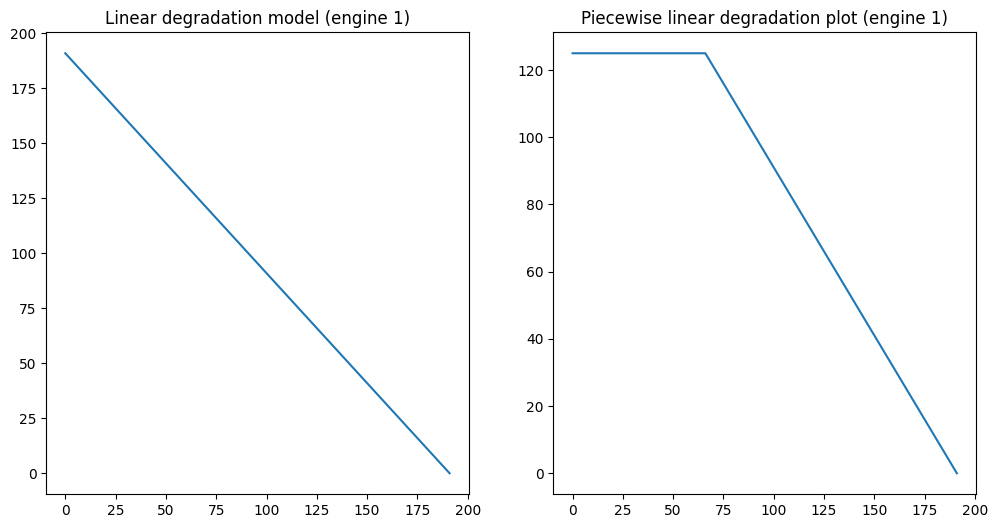

In [8]:
plt.figure(figsize = (12, 6))
plt.subplot(121)
plt.plot(engine_1_linear_degradation_model)
plt.title("Linear degradation model (engine 1)")
plt.subplot(122)
plt.plot(engine_1_piecewise_linear_degradation_model)
plt.title("Piecewise linear degradation plot (engine 1)")
plt.show()

* Observe that while the linear degradation curve starts at 191 and ends at 0, piecewise linear degradation curve starts at 125, stays at 125 for some time and then linearly degrades to 0.

* We can similarly find RUL values for other engines. But individually finding RUL for each engine is boring. So we will write a function that automatically finds RUL values for both models if it is supplied with the total number of cycles.

In [9]:
def process_targets(data_length, early_rul = None):
    """ 
    Takes datalength (i.e., total number of cycles for each engine) and early_rul as input and 
    creates target rul.
    
    Arguments:
        data_length: (scaler) Number of cycles for each engine
        early_rul: (scaler) Early RUL value to be set. When set to `None`, linear degradation
                   curve is used. (deafult: None)

    Returns:
        target_array: (1D float array) Target array
    """
    if early_rul == None:
        return np.arange(data_length-1, -1, -1)
    else:
        early_rul_duration = data_length - early_rul
        if early_rul_duration <= 0:    # This condition is needed when early rul is larger than data_length of an engine
            target_array = np.arange(data_length-1, -1, -1)
            return target_array
        else:
            target_array = np.append(early_rul*np.ones(shape = (early_rul_duration,)), np.arange(early_rul-1, -1, -1))
            return target_array

* Now for any engine, we can find RUL values for both models. For example, we will take engine 7. From above we find that engine 7 fails after 259 cycles. So its data_length is 259.

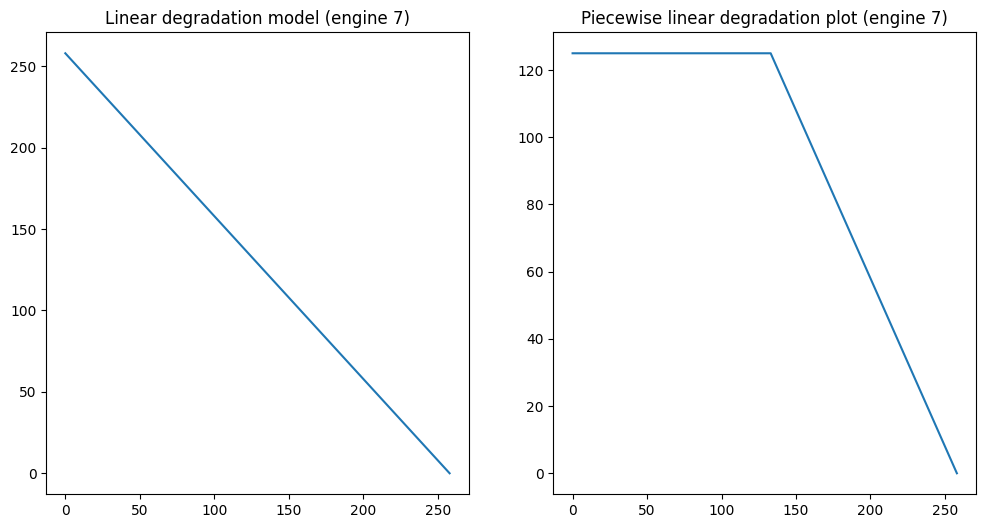

In [10]:
engine_7_linear_degradation_rul = process_targets(259, early_rul = None)
engine_7_piecewise_linear_degradation_rul = process_targets(259, early_rul = 125)
plt.figure(figsize = (12, 6))
plt.subplot(121)
plt.plot(engine_7_linear_degradation_rul)
plt.title("Linear degradation model (engine 7)")
plt.subplot(122)
plt.plot(engine_7_piecewise_linear_degradation_rul)
plt.title("Piecewise linear degradation plot (engine 7)")
plt.show()

* Analyzing Test data

Test data are similar to train data with only one difference. While for training data, data are available until failure for each engine, for test data, it is available for an arbitrary number of cycles. Using the given test data, out goal is to predict RUL. For test data, true RUL values are also available so that we can compare the performance of our prediction algorithm.

In [11]:
import pandas as pd

test_data = pd.read_csv(
    r"C:\sync data\Desktop\Engine failure prediction\Data\test_FD001.txt",
    sep=r"\s+",
    header=None
)
print(test_data.shape)

(13096, 26)


In [12]:
test_data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,21.61,553.90,2388.04,9050.17,1.3,47.20,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,21.61,554.85,2388.01,9054.42,1.3,47.50,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,21.61,554.11,2388.05,9056.96,1.3,47.50,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,21.61,554.07,2388.03,9045.29,1.3,47.28,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,21.61,554.16,2388.01,9044.55,1.3,47.31,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [13]:
np.unique(test_data[0])

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [14]:
test_data.groupby(0)[1].count().values

array([ 31,  49, 126, 106,  98, 105, 160, 166,  55, 192,  83, 217, 195,
        46,  76, 113, 165, 133, 135, 184, 148,  39, 130, 186,  48,  76,
       140, 158, 171, 143, 196, 145,  50, 203, 198, 126, 121, 125,  37,
       133, 123, 156, 172,  54, 152, 146,  73,  78, 303,  74, 144, 189,
       164, 121, 113, 136, 160, 176,  94, 147, 159, 232, 155, 168,  71,
       147,  71, 187,  54, 152,  68, 131, 112, 137,  88, 205, 162,  72,
       101, 133, 213, 162,  73, 172,  34, 110,  56,  68, 177, 146, 234,
       150, 244, 133,  89,  97, 134, 121,  97, 198])

In [15]:
test_data.corr()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
0,1.000000,0.033629,-0.018456,0.002970,NaN,NaN,0.074428,0.062619,0.094717,NaN,0.025681,-0.093310,0.080592,0.044873,NaN,0.103683,-0.093578,0.081118,0.024729,0.084479,NaN,0.082390,NaN,NaN,-0.090654,-0.081445
1,0.033629,1.000000,-0.003184,-0.020543,NaN,NaN,0.348094,0.322121,0.428697,NaN,0.076825,-0.404598,0.312229,0.340687,NaN,0.446071,-0.416962,0.310481,0.257984,0.385036,NaN,0.361176,NaN,NaN,-0.384333,-0.376825
2,-0.018456,-0.003184,1.000000,-0.007701,NaN,NaN,0.007159,0.000522,-0.002406,NaN,-0.008338,0.000436,0.000401,-0.002734,NaN,0.004653,-0.006223,0.011649,-0.008583,0.006341,NaN,-0.002448,NaN,NaN,-0.003114,0.007560
3,0.002970,-0.020543,-0.007701,1.000000,NaN,NaN,-0.019323,-0.014673,-0.023242,NaN,-0.013166,0.028616,-0.025603,0.016284,NaN,-0.031544,0.025507,-0.034281,0.023701,-0.019879,NaN,-0.007585,NaN,NaN,0.007039,0.028477
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.074428,0.348094,0.007159,-0.019323,NaN,NaN,1.000000,0.387655,0.540813,NaN,0.122260,-0.526991,0.526649,0.025602,NaN,0.570150,-0.560245,0.527775,-0.086211,0.496486,NaN,0.423478,NaN,NaN,-0.475045,-0.466920
7,0.062619,0.322121,0.000522,-0.014673,NaN,NaN,0.387655,1.000000,0.467417,NaN,0.101223,-0.481640,0.451400,0.072343,NaN,0.503727,-0.489609,0.447226,-0.029337,0.427995,NaN,0.379133,NaN,NaN,-0.413866,-0.409713
8,0.094717,0.428697,-0.002406,-0.023242,NaN,NaN,0.540813,0.467417,1.000000,NaN,0.142806,-0.650700,0.635391,0.029533,NaN,0.687747,-0.675109,0.631043,-0.105956,0.589177,NaN,0.517864,NaN,NaN,-0.577188,-0.562496
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


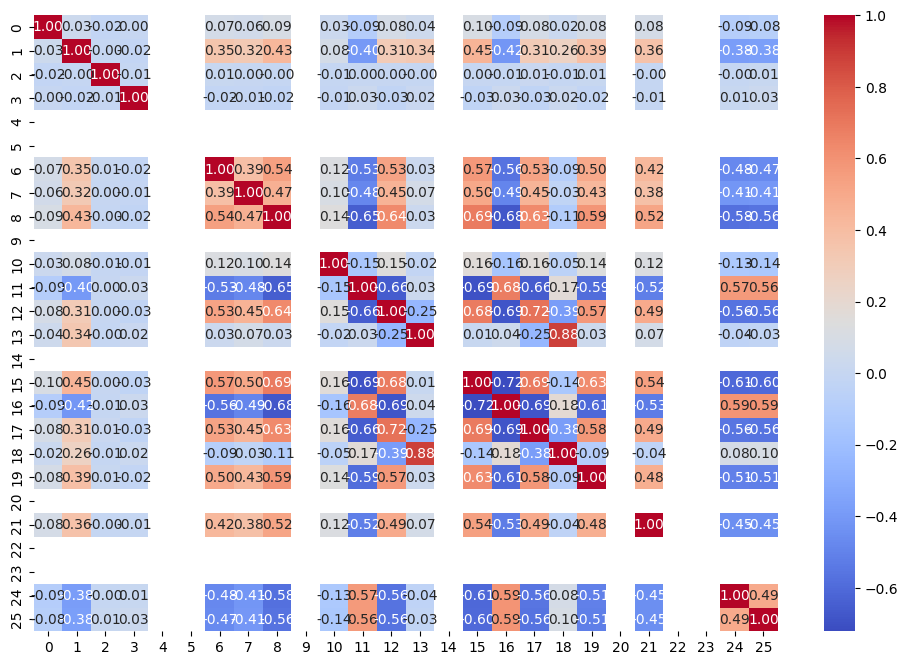

In [16]:
# Compute correlation matrix
corr_mat = test_data.corr()

# Set figure size (width, height in inches)
plt.figure(figsize=(12, 8))   # Try (15,10) for larger datasets

# Draw heatmap
sns.heatmap(corr_mat, annot=True, cmap="coolwarm", fmt=".2f")

# Show plot
plt.show()

* We can see that data for 31 cycles are available for engine 1 in test set. Data for 49 cycles are available for engine 2, and so on. Using the available data our goal is to predict RUL for each engine.

In [17]:
true_rul = pd.read_csv(r'C:\sync data\Desktop\Engine failure prediction\Data\RUL_FD001.txt', sep = r'\s+', header = None)
true_rul[0].values

array([112,  98,  69,  82,  91,  93,  91,  95, 111,  96,  97, 124,  95,
       107,  83,  84,  50,  28,  87,  16,  57, 111, 113,  20, 145, 119,
        66,  97,  90, 115,   8,  48, 106,   7,  11,  19,  21,  50, 142,
        28,  18,  10,  59, 109, 114,  47, 135,  92,  21,  79, 114,  29,
        26,  97, 137,  15, 103,  37, 114, 100,  21,  54,  72,  28, 128,
        14,  77,   8, 121,  94, 118,  50, 131, 126, 113,  10,  34, 107,
        63,  90,   8,   9, 137,  58, 118,  89, 116, 115, 136,  28,  38,
        20,  85,  55, 128, 137,  82,  59, 117,  20])

* An RUL value of 112 for engine 1 in test set means that it failed 112 cycles after 31st cycle. So engine 1 ran for (31+112) cycles before it failed. Similarly engine two failed 98 cycles after 49th cycle. So engine 2 ran for (49 + 98) cycles in total before it failed. Similar calculation can be done for other engines in test set.

* For all our analysis, we will only use sensor measurements. First two columns of training data contain engine and cycle information respectively. So we don't need those columns while training an algorithm. Similarly columns 3-5 contain operational settings. We will also don't use those for training. It should be noted that some authors do use operational setting values to train their algorithm. But we will not do that. We will only use columns 6-26 values to train our algorithm as those are sensor measurements. But before we use those columns, we would first like to have some rough idea about the contents of the data. For that we will plot density plots of all sensor measurements of training data.

Boxplot of sensor measurements (columns 6-26)

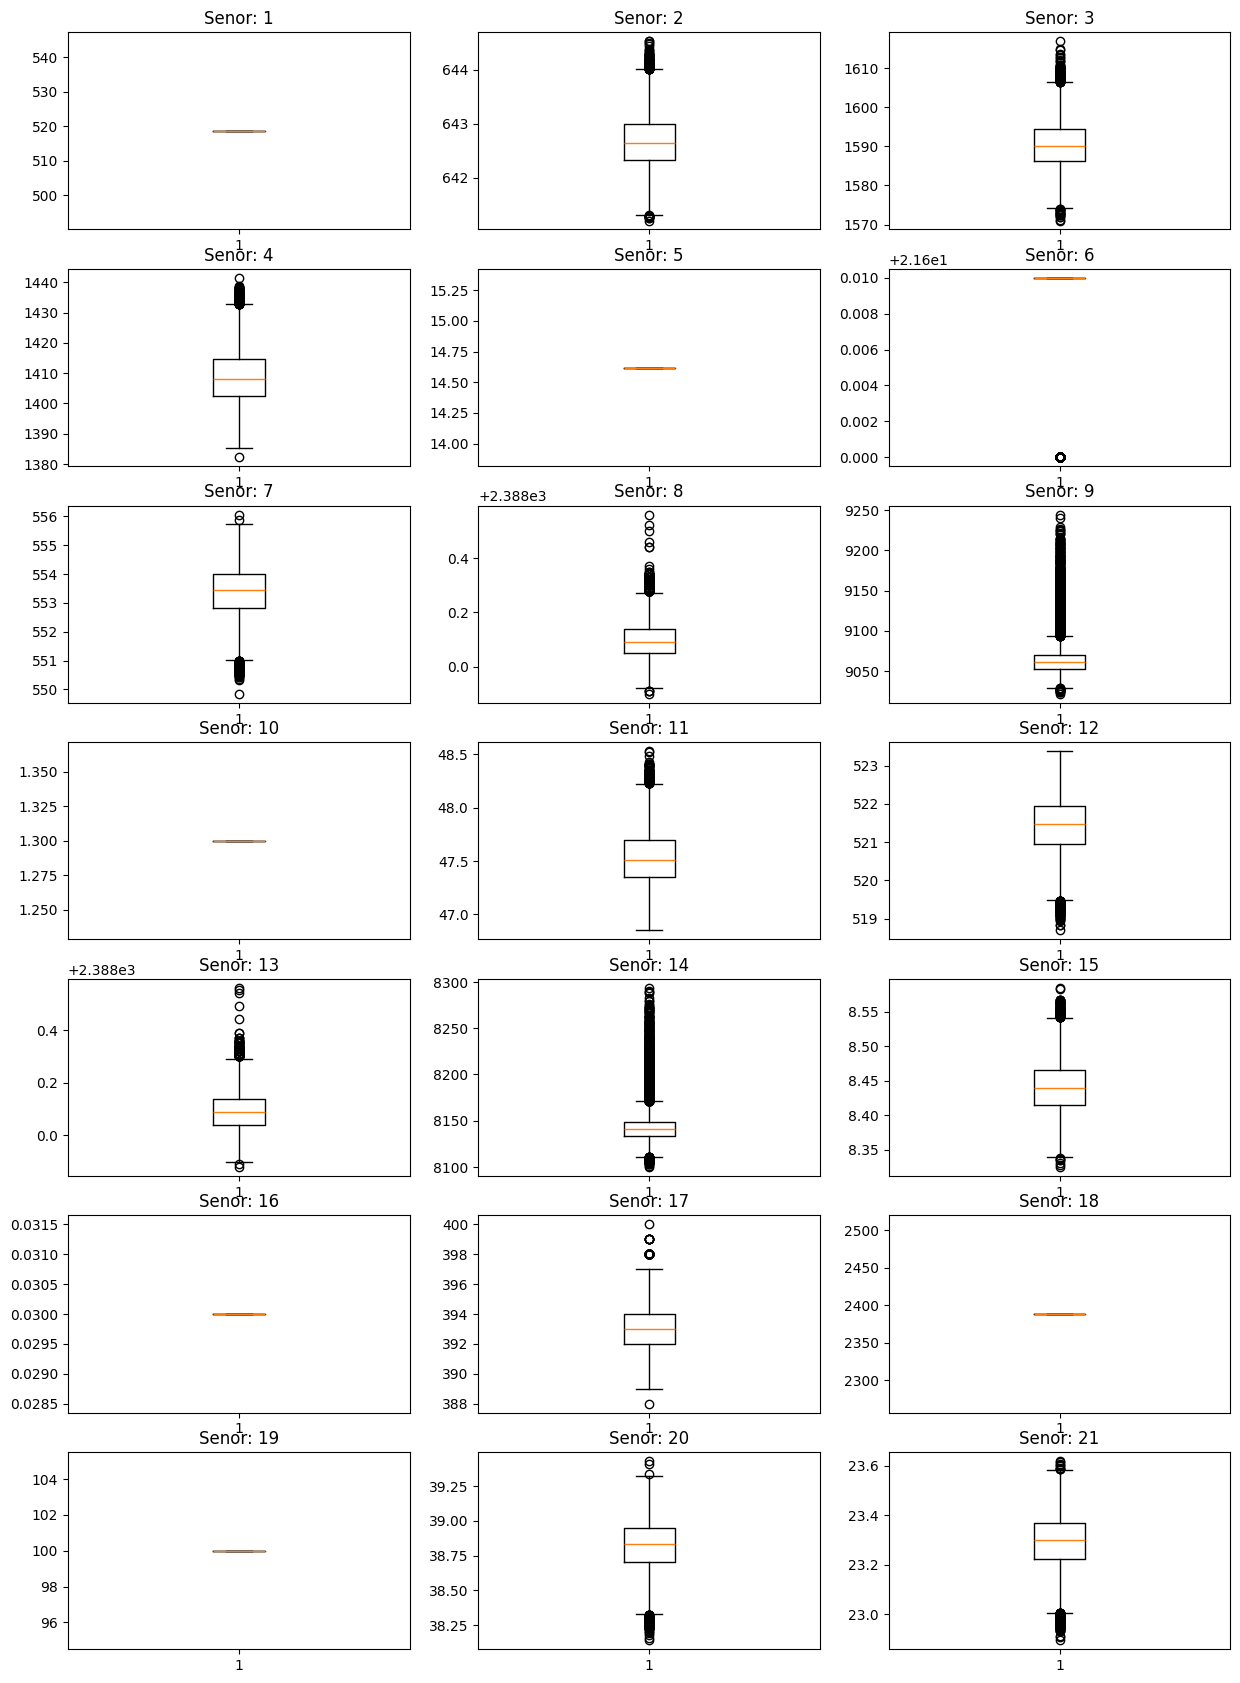

In [18]:
plt.figure(figsize = (15, 21))
for i in np.arange(5, 26):        # column 5 in python means actual 6th column
    temp = train_data.iloc[:, i]
    plt.subplot(7,3, i-4)
    plt.boxplot(temp)
    plt.title("Senor: "+ str(i-4))
plt.show()

In [19]:
train_data[10].value_counts()

10
21.61    20225
21.60      406
Name: count, dtype: int64

* So column 11 contains two constant values: 21.61 and 21.60. Frequency of 21.61 is 20225. As the values are close to each other, we can consider all the values to be constant.

* Constant values don't help us much while training an algorithm. Sometimes we also have to normalize data (subtract mean and divide by standard deviation). If a column contains a constant value, its standard deviation is zero. So normalization of that column is not possible as it requires division by zero. For these reasons, we will drop the columns containing constant values.

* We can plot density plot of other columns as follows.

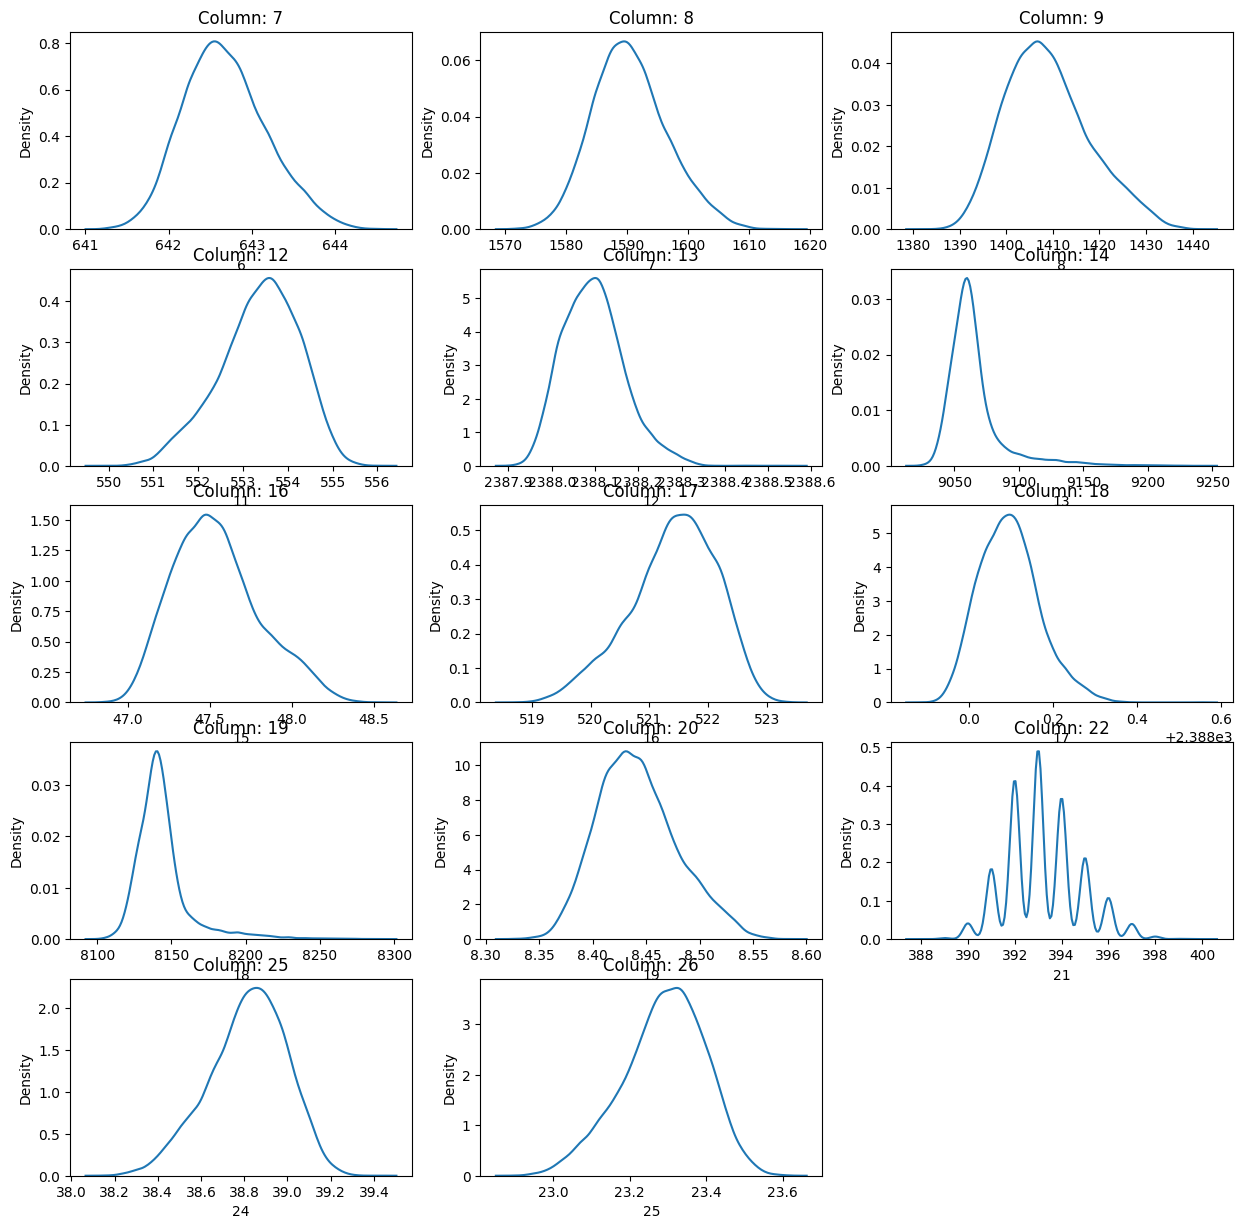

In [20]:
plt.figure(figsize = (15, 21))
for i,j in enumerate([6, 7, 8, 11, 12, 13, 15, 16, 17, 18, 19, 21, 24, 25]):
    temp = train_data.iloc[:, j]
    plt.subplot(7,3, i+1)
    sns.kdeplot(temp, legend = False)
    plt.title("Column: "+ str(j+1))
plt.show()

* An algorithm generalizes well (i.e., its performance on unseen data is good) if unseen data is similar in distribution to training data. Unseen data need not be exactly of same distribution as of training data but it should not be very different from training data.

* Here, we will just check the distribution of training and test data. It should be noted that test data should never be used while training an algorithm. Training an algorithm is an iterative process. With more parameters, it is very likely that training error reduces nearly zero. But its performance on new unseen data is not that good. In that case, we say that the model has overfit the training data (or memorized the training examples). Therefore, while training we have to devise some way to check whether the model is learning something or just memorizing the training data. To do that, we extract a portion of training data as validation set and use the validation set to check performance of trained model at each iteration. Once we are satisfied with the final model, we can use it to evaluate its performance on test data. While iterating over different models, we should avoid overfitting the validation data.

* Here, we will only show the density plot of training as well as test data.

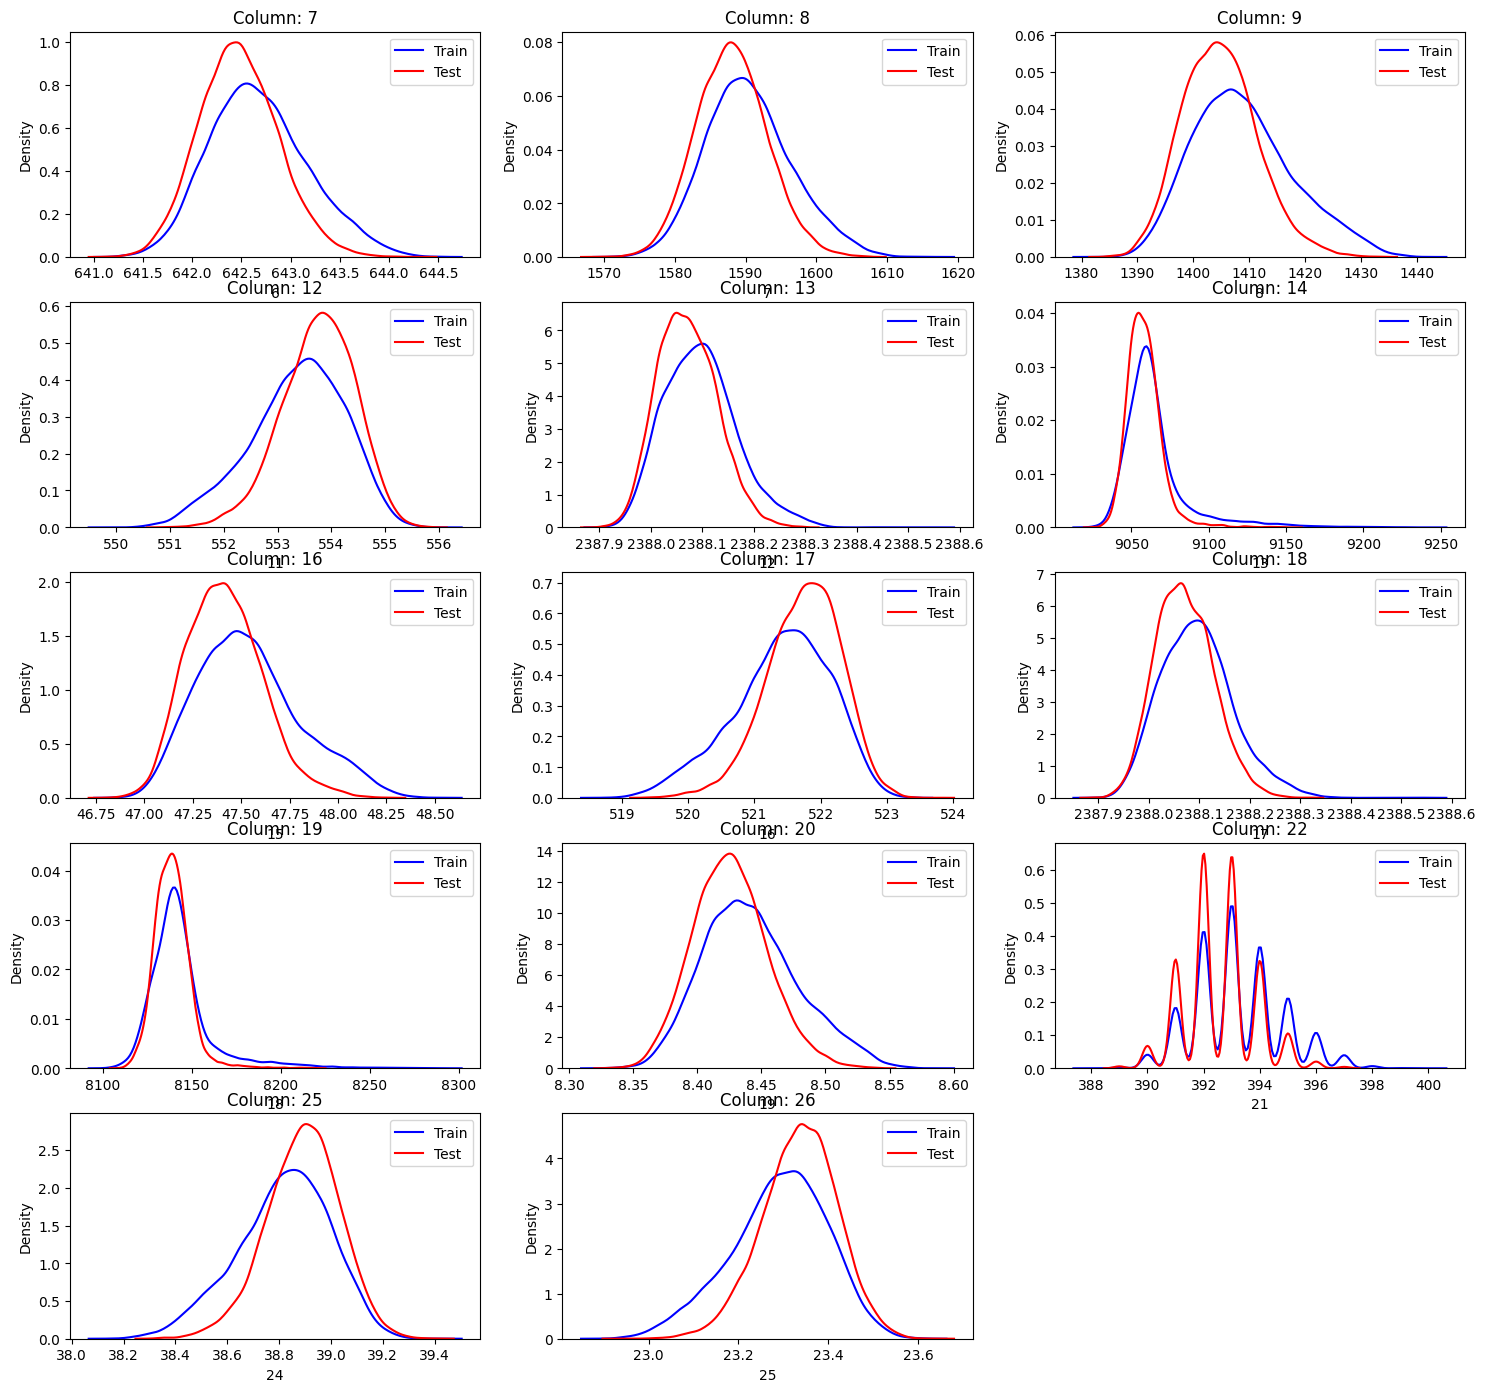

In [21]:
plt.figure(figsize = (18, 24))
for i,j in enumerate([6, 7, 8, 11, 12, 13, 15, 16, 17, 18, 19, 21, 24, 25]):
    temp_train = train_data.iloc[:, j]
    temp_test = test_data.iloc[:, j]
    plt.subplot(7,3, i+1)
    sns.kdeplot(temp_train, legend = False, color = "blue", label = "Train")
    sns.kdeplot(temp_test, legend = False, color = "red", label = "Test")
    plt.title("Column: "+ str(j+1))
    plt.legend()
plt.show()

* Though not exact, test data has a similar distribution as training data. So if we design our algorithm carefully, it will generalize well.

* Preparing data for training algorithm
While preparing data for a training algorithm, we have to consider several factors. Some of the factors are listed below.

* Should data be scaled?
If data are scaled, should a single scaling be applied to all engines or individual scaling be applied for every engine?
Should linear degradation model or piecewise linear degradation model for RUL be used?
If piecewise linear degradation model is used, what is the value of early RUL?
To make things more concrete, we will specify the shapes of array. Our initial training data have a shape of 
(
20631
×
26
)
. We won't use engine info and operational settings for training. So after removing first 5 columns, our training data have a shape of 
(
20631
×
21
)
. From our previous data plotting, we found that 7 columns contain constant values. So we remove those columns. After removing those columns, our data have a shape of 
(
20631
×
14
)
. We choose to apply scaling individually to every engine.

* For some applications, we consider each row of the data matrix as a data point and our training model is trained accordingly. But for some other applications, we use a window of data. For example, if window length is, say, 20, size of data for training would be 
(
20
×
14
)
. There may be overlap between windows. The following figure illustrates it for a toy dataset with 6 rows and 4 columns.

* Therefore, we will write a function, general enough, such that we can generate any type of data at a later stage depending upon our need. For that we need two custom functions: process targets and process_input_data_with_targets. We have already used the first function. Second function is defined as follows.

In [22]:
def process_input_data_with_targets(input_data, target_data = None, window_length = 1, shift = 1):
    """
    Depending on values of window_length and shift, this function generates batchs of data and targets 
    from `input_data` and `target_data`. `target_data` is optional. If no `target_data` is given, i.e., 
    `target_data = None`, no `output_targets` are generated. The following formula is used to determine
    number of batches. Please note that, here we use the term `batch` in a different sense than its usual
    meaning in deep learning.  
    
    Number of batches = int(np.floor((len(input_data) - window_length)/shift)) + 1
    
    **We don't check input dimensions using exception handling. So readers should be careful while using these
    functions. If input data are not of desired dimension, either error occurs or something undesirable is 
    produced as output.**
    
    Arguments:
        input_data: (Must be 2D array) input data to function 
        target_data (optional): (Must be 1D array) Input rul values (default: None)
        window_length: (scalar) window length of data (default: 1)
        shift: (scalar) Distance by which the window moves for next batch. This is closely related to overlap
               between data. For example, if window length is 30 and shift is 1, there is an overlap of 
               29 data points between two consecutive batches (default: 1)
        
    Returns:
        output_data: (2D float array) Output data that would be passed to machine learning model
        output_targets (optional): (1D float array) Output targets. Only generated if `target_data` is
                                   passed as argument.
    """
    num_batches = int(np.floor((len(input_data) - window_length)/shift)) + 1
    num_features = input_data.shape[1]
    output_data = np.repeat(np.nan, repeats = num_batches * window_length * num_features).reshape(num_batches, window_length,
                                                                                                  num_features)
    if target_data is None:
        for batch in range(num_batches):
            output_data[batch,:,:] = input_data[(0+shift*batch):(0+shift*batch+window_length),:]
        return output_data
    else:
        output_targets = np.repeat(np.nan, repeats = num_batches)
        for batch in range(num_batches):
            output_data[batch,:,:] = input_data[(0+shift*batch):(0+shift*batch+window_length),:]
            output_targets[batch] = target_data[(shift*batch + (window_length-1))]
        return output_data, output_targets

* In the above function, we have used an argument shift. It is closely related to number of overlap rows. For example, if window length is 30 and shift is 2, it would mean there is an overlap of 28 rows between successive data batches.

#### Check whether the functions works as intended or not

In [23]:
data = np.array([[1,2,3,4,5],
                 [6,7,8,9,10],
                 [11,12,13,14,15],
                 [16,17,18,19,20],
                 [21,22,23,24,25],
                 [26,27,28,29,30]])
ruls = np.array([31,32,33,34,35,36])
print("Data:")
print(data)
print()
print("RUL:")
print(ruls)

Data:
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]
 [26 27 28 29 30]]

RUL:
[31 32 33 34 35 36]


In [24]:
check_data, check_rul = process_input_data_with_targets(data,target_data = ruls, window_length = 3, shift = 1)
print(check_data)
print()
print(check_rul)

[[[ 1.  2.  3.  4.  5.]
  [ 6.  7.  8.  9. 10.]
  [11. 12. 13. 14. 15.]]

 [[ 6.  7.  8.  9. 10.]
  [11. 12. 13. 14. 15.]
  [16. 17. 18. 19. 20.]]

 [[11. 12. 13. 14. 15.]
  [16. 17. 18. 19. 20.]
  [21. 22. 23. 24. 25.]]

 [[16. 17. 18. 19. 20.]
  [21. 22. 23. 24. 25.]
  [26. 27. 28. 29. 30.]]]

[33. 34. 35. 36.]


In [25]:
check_data_2, check_rul_2 = process_input_data_with_targets(data,target_data = ruls, window_length = 3, shift = 2)
print(check_data_2)
print()
print(check_rul_2)

[[[ 1.  2.  3.  4.  5.]
  [ 6.  7.  8.  9. 10.]
  [11. 12. 13. 14. 15.]]

 [[11. 12. 13. 14. 15.]
  [16. 17. 18. 19. 20.]
  [21. 22. 23. 24. 25.]]]

[33. 35.]


Note that in our function, target_data argument is optional. If we don't pass any data in that argument, we get only batched data as output. This is useful for preprocessing test data for which we don't know target RUL values. The following cell illustrates this with an example.

In [26]:
check_data_new = process_input_data_with_targets(data, target_data = None, window_length = 4, shift = 1)
check_data_new

array([[[ 1.,  2.,  3.,  4.,  5.],
        [ 6.,  7.,  8.,  9., 10.],
        [11., 12., 13., 14., 15.],
        [16., 17., 18., 19., 20.]],

       [[ 6.,  7.,  8.,  9., 10.],
        [11., 12., 13., 14., 15.],
        [16., 17., 18., 19., 20.],
        [21., 22., 23., 24., 25.]],

       [[11., 12., 13., 14., 15.],
        [16., 17., 18., 19., 20.],
        [21., 22., 23., 24., 25.],
        [26., 27., 28., 29., 30.]]])

* Now we are ready to use the functions to preprocess the actual CMAPSS data. For this demonstration, we will use following function argument values.

* window_length = 30
shift = 1 (It is equivalent to overlap of 29 rows between successive windowed data)
early_rul = 125
We have also used

* MinMaxScaling with feature range (-1, 1). We can change this to StandardScaler if we want. Scaling is applied individually to each engine of training set. The scaling parameters learned from training data is then used to scale test data of corresponding engine.
How to preprocess test data?
For each engine in the test set, we need to predict one RUL value. To predict one RUL value, we need one example of test data for each engine. So the obvious choice is to use the last example of test data for each engine. If an example consists of a window of data, for a given window length, we will take the last window of data that can be extracted from test set for a particular engine. For example, assume that for a particular engine, test set data has a shape of  
(
45
×
14
)
 . For window_length = 30, and shift = 1, we can extract 16 windowed datasets of size  
(
30
×
14
)
 . But we have to predict only one number as RUL for that engine. So, out of the 13 datasets of size  
(
30
×
14
)
 , we will use the last one for predicting RUL.

* The above approach, though technically correct, is prone to mistakes. What happens if the measurements of last example have some outliers? In that case our prediction would be way off. One approach to circumvent this issue is to take, say, last 5 examples instead of only the last example for each engine. Then we will get 5 RUL prediction values. We can average those to come up with our final estimate of RUL. In this way our RUL estimate will be a little conservative but robust against outliers in the last test example.

* In the following cell, we will write a function that prepares a number of test examples as per user input.

In [27]:
def process_test_data(test_data_for_an_engine, window_length, shift, num_test_windows = 1):
    """ 
    This function takes test data for an engine as first input. The next two inputs,
    window_length and shift are same as other functions. 
    
    Finally it takes num_test_windows as the last input. num_test_windows sets how many examples we
    want from test data (from last). By default it extracts only the last example.
    
    The function returns last examples and number of last examples (a scaler) as output. 
    We need the second output later. If we are extracting more than 1 last examples, we have to 
    average their prediction results. The second scaler helps us do just that.

    Arguments:
        test_data_for_an_engine: (2D array) input test data
        window_length: (scalar) window length of data
        shift: (scalar) Distance by which the window moves for next batch. This is closely related to overlap
               between data. For example, if window length is 30 and shift is 1, there is an overlap of 
               29 data points between two consecutive batches.
        num_test_windows: (scalar) Number of examples to take from last. (default: 1)

    Returns:
        batched_test_data_for_an_engine: (2D array) Batched test data. Please note that, here we have used the term `batch`
                                         in a different sense than its usual meaning in deep learning.
        extracted_num_test_windows: (scalar) Extracted number of test examples from last. If `num_test_windows` number of
                                    examples can't be extracted from test data, in that case `extracted_num_test_windows`
                                    is less than `num_test_windows`. 
    """
    max_num_test_batches = int(np.floor((len(test_data_for_an_engine) - window_length)/shift)) + 1
    if max_num_test_batches < num_test_windows:
        required_len = (max_num_test_batches -1)* shift + window_length
        batched_test_data_for_an_engine = process_input_data_with_targets(test_data_for_an_engine[-required_len:, :],
                                                                          target_data = None,
                                                                          window_length = window_length, shift = shift)
        extracted_num_test_windows = max_num_test_batches
        return batched_test_data_for_an_engine, extracted_num_test_windows
    else:
        required_len = (num_test_windows - 1) * shift + window_length
        batched_test_data_for_an_engine = process_input_data_with_targets(test_data_for_an_engine[-required_len:, :],
                                                                          target_data = None,
                                                                          window_length = window_length, shift = shift)
        extracted_num_test_windows = num_test_windows
        return batched_test_data_for_an_engine, extracted_num_test_windows

Now we will check whether the above function works as intended or not.

In [28]:
check_data = np.reshape(np.arange(24), newshape = (6,4))
check_data

C:\Users\Gopi\AppData\Local\Temp\ipykernel_19840\2568154457.py:1: DeprecationWarning: `newshape` keyword argument is deprecated, use `shape=...` or pass shape positionally instead. (deprecated in NumPy 2.1)
  check_data = np.reshape(np.arange(24), newshape = (6,4))


array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [29]:
last_examples, num_last_examples = process_test_data(check_data, window_length = 2, shift = 1, num_test_windows= 1)
print(last_examples)
print()
print(num_last_examples)

[[[16. 17. 18. 19.]
  [20. 21. 22. 23.]]]

1


In [30]:
last_examples, num_last_examples = process_test_data(check_data, window_length = 2, shift = 1, num_test_windows= 3)
print(last_examples)
print()
print(num_last_examples)

[[[ 8.  9. 10. 11.]
  [12. 13. 14. 15.]]

 [[12. 13. 14. 15.]
  [16. 17. 18. 19.]]

 [[16. 17. 18. 19.]
  [20. 21. 22. 23.]]]

3


If we set window_length = 1, and num_test_windows = 3, we will simply select last 3 rows of test data. For the above toy data, we get the following result.

In [31]:
last_examples, num_last_examples = process_test_data(check_data, window_length = 1, shift = 1, num_test_windows= 3)
print(last_examples)
print()
print(num_last_examples)

[[[12. 13. 14. 15.]]

 [[16. 17. 18. 19.]]

 [[20. 21. 22. 23.]]]

3


#### How to scale data?
For some algorithms, it is required to scale the data first before feeding it into the algorithm. We can use built-in scikit-learn scalers like StandardScaler, MinMaxScaler, etc. We will first scale the training data individually for each engine. Using the scaled parameters, we will then scale the data for corresponding test engine. For example, FD001 contains training data for 100 engines. So we will individually scale training data for 100 engines. Test data for FD001 also contains 100 engines. We will use scaling parameters of training data to scale corresponding engine data in test set.

When there is a discrepancy in number of engines between training and test set (this occurs in FD002 and FD004), we scale only those training data for which there is a corresponding engine in test set. Again to give a concrete example, FD004 contains 249 training engines but 248 test engines. So while scaling data for this case, we ignore data corresponding to engine 249 in training set as there is no corresponding data in test set.

In the following cell, scaling is performed using 3 lines of code. If for some application scaling is not required, then just comment those 3 lines.

In the following cell, we will preprocess both training and test data with scaling.

In [32]:
window_length = 30
shift = 1
early_rul = 125             # Set to None for linear degradation model
processed_train_data = []
processed_train_targets = []

# How many test examples to take for each engine. If set to 1 (this is the default), only last example of test data for 
# each engine are taken. If set to a different number, that many examples from last are taken. 
# Final output for an engine will be the average of output of all examples for that engine.
num_test_windows = 1     # Number of examples. Change to a different number to select that many test examples for each engine.
processed_test_data = []
num_test_windows_list = []  # This list keeps track of number of examples for all engines in the test set.

num_machines = np.min([len(train_data[0].unique()), len(test_data[0].unique())])

for i in np.arange(1, num_machines + 1):
    
    temp_train_data = train_data[train_data[0] == i].drop(columns=[0,1,2,3,4,5,9,10,14,20,22,23]).values
    temp_test_data = test_data[test_data[0] == i].drop(columns=[0,1,2,3,4,5,9,10,14,20,22,23]).values
    
    # Verify if data of given window length can be extracted from both training and test data
    if (len(temp_test_data) < window_length):
        print("Test engine {} doesn't have enough data for window_length of {}".format(i, window_length))
        raise AssertionError("Window length is larger than number of data points for some engines. "
                             "Try decreasing window length.")
    elif (len(temp_train_data) < window_length):
        print("Train engine {} doesn't have enough data for window_length of {}".format(i, window_length))
        raise AssertionError("Window length is larger than number of data points for some engines. "
                             "Try decreasing window length.")
    
    # We have used MinMaxScaler. Use a different scaler if you want.
    # Or just comment the following 3 lines if no scaling is required.
    scaler = MinMaxScaler(feature_range = (-1, 1))
    temp_train_data = scaler.fit_transform(temp_train_data)
    temp_test_data = scaler.transform(temp_test_data)    
    
    temp_train_targets = process_targets(data_length = temp_train_data.shape[0], early_rul = early_rul)
    data_for_a_machine, targets_for_a_machine = process_input_data_with_targets(temp_train_data, temp_train_targets, 
                                                                                window_length = window_length, shift = shift)
    
    # Prepare test data
    test_data_for_an_engine, num_windows = process_test_data(temp_test_data, window_length = window_length, shift = shift,
                                                             num_test_windows = num_test_windows)
    
    processed_train_data.append(data_for_a_machine)
    processed_train_targets.append(targets_for_a_machine)
    
    processed_test_data.append(test_data_for_an_engine)
    num_test_windows_list.append(num_windows)

processed_train_data = np.concatenate(processed_train_data)
processed_train_targets = np.concatenate(processed_train_targets)
processed_test_data = np.concatenate(processed_test_data)
true_rul = true_rul[0].values

# Shuffle data
index = np.random.permutation(len(processed_train_targets))
processed_train_data, processed_train_targets = processed_train_data[index], processed_train_targets[index]

In [33]:
print(processed_train_data.shape)
print(processed_train_targets.shape)
print(processed_test_data.shape)
print(true_rul.shape)

(17731, 30, 14)
(17731,)
(100, 30, 14)
(100,)


In [34]:
train_data = pd.read_csv(r"C:\sync data\Desktop\Engine failure prediction\Data\train_FD001.txt", sep= r"\s+", header = None)
test_data = pd.read_csv(r"C:\sync data\Desktop\Engine failure prediction\Data\test_FD001.txt", sep = r"\s+", header = None)
true_rul = pd.read_csv(r"C:\sync data\Desktop\Engine failure prediction\Data\RUL_FD001.txt", sep = r'\s+', header = None)

window_length = 30
shift = 1
early_rul = 125            
processed_train_data = []
processed_train_targets = []

# How many test windows to take for each engine. If set to 1 (this is the default), only last window of test data for 
# each engine is taken. If set to a different number, that many windows from last are taken. 
# Final output is the average output of all windows.
num_test_windows = 1     
processed_test_data = []
num_test_windows_list = []

columns_to_be_dropped = [0,1,2,3,4,5,9,10,14,20,22,23]

train_data_first_column = train_data[0]
test_data_first_column = test_data[0]

# Scale data for all engines
scaler = StandardScaler()
train_data = scaler.fit_transform(train_data.drop(columns = columns_to_be_dropped))
test_data = scaler.transform(test_data.drop(columns = columns_to_be_dropped))

train_data = pd.DataFrame(data = np.c_[train_data_first_column, train_data])
test_data = pd.DataFrame(data = np.c_[test_data_first_column, test_data])

num_train_machines = len(train_data[0].unique())
num_test_machines = len(test_data[0].unique())

# Process training and test data separately as number of engines in training and test set may be different.
# As we are doing scaling for full dataset, we are not bothered by different number of engines in training and test set.

# Process training data
for i in np.arange(1, num_train_machines + 1):
    temp_train_data = train_data[train_data[0] == i].drop(columns = [0]).values
    
    # Verify if data of given window length can be extracted from training data
    if (len(temp_train_data) < window_length):
        print("Train engine {} doesn't have enough data for window_length of {}".format(i, window_length))
        raise AssertionError("Window length is larger than number of data points for some engines. "
                             "Try decreasing window length.")
        
    temp_train_targets = process_targets(data_length = temp_train_data.shape[0], early_rul = early_rul)
    data_for_a_machine, targets_for_a_machine = process_input_data_with_targets(temp_train_data, temp_train_targets, 
                                                                                window_length = window_length, shift = shift)
    
    processed_train_data.append(data_for_a_machine)
    processed_train_targets.append(targets_for_a_machine)

processed_train_data = np.concatenate(processed_train_data)
processed_train_targets = np.concatenate(processed_train_targets)

# Process test data
for i in np.arange(1, num_test_machines + 1):
    temp_test_data = test_data[test_data[0] == i].drop(columns = [0]).values
    
    # Verify if data of given window length can be extracted from test data
    if (len(temp_test_data) < window_length):
        print("Test engine {} doesn't have enough data for window_length of {}".format(i, window_length))
        raise AssertionError("Window length is larger than number of data points for some engines. "
                             "Try decreasing window length.")
    
    # Prepare test data
    test_data_for_an_engine, num_windows = process_test_data(temp_test_data, window_length = window_length, shift = shift,
                                                             num_test_windows = num_test_windows)
    
    processed_test_data.append(test_data_for_an_engine)
    num_test_windows_list.append(num_windows)

processed_test_data = np.concatenate(processed_test_data)
true_rul = true_rul[0].values

# Shuffle training data
index = np.random.permutation(len(processed_train_targets))
processed_train_data, processed_train_targets = processed_train_data[index], processed_train_targets[index]

print("Processed training data shape: ", processed_train_data.shape)
print("Processed training rul shape: ", processed_train_targets.shape)
print("Processed test data shape: ", processed_test_data.shape)
print("True RUL shape: ", true_rul.shape)

Processed training data shape:  (17731, 30, 14)
Processed training rul shape:  (17731,)
Processed test data shape:  (100, 30, 14)
True RUL shape:  (100,)


In [36]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [38]:
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential # Assuming Keras/Tensorflow for LSTM
from tensorflow.keras.layers import LSTM, Dense

# --- 0. Data Loading and Column Naming (Essential Setup) ---
# Define standard column names for the FD001 dataset for readability
cols = [f'Op_Setting_{i}' for i in range(1, 4)] + [f'Sensor_{i}' for i in range(1, 22)]
column_names = ['Engine_No', 'Cycle'] + cols

# Reload/Rename the dataframes (assuming you have already run the previous loading cells)
# The user's initial load was header=None, so we re-read for clean column naming
train_data = pd.read_csv(
    r"C:\sync data\Desktop\Engine failure prediction\Data\train_FD001.txt",
    sep=r"\s+", header=None, names=column_names
)
test_data = pd.read_csv(
    r"C:\sync data\Desktop\Engine failure prediction\Data\test_FD001.txt",
    sep=r"\s+", header=None, names=column_names
)
# true_rul is typically a single column file with RUL for the *last* cycle of each test engine
true_rul = pd.read_csv(
    r"C:\sync data\Desktop\Engine failure prediction\Data\RUL_FD001.txt",
    sep=r"\s+", header=None, names=['RUL']
).dropna(axis=1) # Drop the trailing NaN column

print("Initial Training Data Shape:", train_data.shape)

# --- 1. Create the Training RUL Target Feature ---
RUL_LIMIT = 125 # Common industry practice: Cap RUL to a max value

def calculate_RUL(df):
    """Calculates Remaining Useful Life (RUL) for each engine cycle."""
    # Find the max cycle for each engine
    max_cycle_df = df.groupby('Engine_No')['Cycle'].max().reset_index()
    max_cycle_df.columns = ['Engine_No', 'Max_Cycle']

    # Merge max cycle back to the main DataFrame
    df = df.merge(max_cycle_df, on='Engine_No', how='left')

    # Calculate RUL
    df['RUL'] = df['Max_Cycle'] - df['Cycle']
    df.drop('Max_Cycle', axis=1, inplace=True)

    # Apply Piecewise Linear Degradation (Washing-out effect)
    # The RUL is capped at RUL_LIMIT. This assumes no degradation before this limit.
    df['RUL'] = df['RUL'].apply(lambda x: min(x, RUL_LIMIT))

    return df

train_data = calculate_RUL(train_data)
print("RUL Target Generated. Max RUL:", train_data['RUL'].max())

# --- 2. Feature Selection: Drop Constant and Unused Columns ---
# Constant columns identified by zero variance in your initial analysis (0-indexed in the original file)
# Column 4 (Op_Setting_3), Column 5 (Sensor_1), Column 9 (Sensor_5), Column 14 (Sensor_10)
# Column 20 (Sensor_16), Column 22 (Sensor_18), Column 23 (Sensor_19)

# Corresponding names to drop:
constant_cols_to_drop = [
    'Op_Setting_3', 'Sensor_1', 'Sensor_5', 'Sensor_10', 'Sensor_16', 'Sensor_18', 'Sensor_19'
]

# We will keep Op_Setting_1 and Op_Setting_2 as they can provide context for sensor readings.
# We will also keep Engine_No, Cycle, and RUL (in train_data) for sequence generation.
cols_to_keep = ['Engine_No', 'Cycle', 'RUL'] + [
    col for col in column_names if col not in ['Engine_No', 'Cycle'] and col not in constant_cols_to_drop
]

# Select the features for scaling
feature_cols = [col for col in cols_to_keep if col not in ['Engine_No', 'Cycle', 'RUL']]

# Apply feature selection
train_data_selected = train_data[cols_to_keep].copy()
test_data_selected = test_data[[col for col in cols_to_keep if col != 'RUL']].copy()

print("Selected feature columns for scaling:", feature_cols)

# --- 3. Feature Scaling (MinMaxScaler) ---
scaler = MinMaxScaler()

# 3a. Fit the scaler ONLY on the training data's features
train_data_selected[feature_cols] = scaler.fit_transform(train_data_selected[feature_cols])

# 3b. Transform the test data using the training scaler to prevent data leakage
test_data_selected[feature_cols] = scaler.transform(test_data_selected[feature_cols])

print("Data successfully scaled using MinMaxScaler fitted on training features.")

# --- 4. Prepare for Sequence Modeling (Windowing Function) ---
def sequence_generator(
    df, features, target=None, window_length=50, shift=1
):
    """
    Transforms a 2D tabular dataframe into a 3D sequence array for LSTM.

    Args:
        df (pd.DataFrame): Input data (scaled features).
        features (list): List of feature column names.
        target (str, optional): Name of the RUL target column. Defaults to None.
        window_length (int): The length of the look-back window (e.g., 50 cycles).
        shift (int): How many cycles to shift the window by.

    Returns:
        tuple: (sequences, targets) where sequences is 3D (samples, time_steps, features)
               and targets is 1D (samples,).
    """
    sequences = []
    targets = []

    # Process engine by engine to ensure continuity in sequences
    for engine_id in df['Engine_No'].unique():
        engine_df = df[df['Engine_No'] == engine_id].reset_index(drop=True)
        data = engine_df[features].values

        # The loop starts after the first window_length cycles
        for i in range(window_length, len(engine_df) + 1, shift):
            # Sequence: the past 'window_length' cycles
            sequence = data[i - window_length:i, :]
            sequences.append(sequence)

            # Target: The RUL value *at the end of that sequence*
            if target:
                target_value = engine_df.loc[i - 1, target]
                targets.append(target_value)

    # Convert to numpy arrays for Keras/Tensorflow
    sequences = np.array(sequences)
    targets = np.array(targets) if target else None

    return sequences, targets

print("Sequence generation utility function 'sequence_generator' defined.")

# --- Next Step for User (Demonstration of Step 4) ---
# window_length = 50 # Example window size
# shift = 1 # Example shift size

# # Generate training data sequences
# X_train, y_train = sequence_generator(
#     train_data_selected,
#     features=feature_cols,
#     target='RUL',
#     window_length=window_length,
#     shift=shift
# )
# print(f"\nTraining Sequences (X_train) Shape: {X_train.shape}")
# print(f"Training Targets (y_train) Shape: {y_train.shape}")

# # You would use a slightly different approach for test data to predict only the *last* RUL value.
# # (This is the approach hinted at by the code snippet in your notebook)

Initial Training Data Shape: (20631, 26)
RUL Target Generated. Max RUL: 125
Selected feature columns for scaling: ['Op_Setting_1', 'Op_Setting_2', 'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_6', 'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15', 'Sensor_17', 'Sensor_20', 'Sensor_21']
Data successfully scaled using MinMaxScaler fitted on training features.
Sequence generation utility function 'sequence_generator' defined.


In [39]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# --- Constants & Data Structure (Assuming available from previous step) ---
# NOTE: Replace these with your actual DataFrames and feature list if needed.
# For this code to run, you must have 'train_data_selected', 'test_data_selected', and 'true_rul' DataFrames ready.
# If they are not available, you must run the entire preprocessing pipeline again.

# Example constants (from the previous step's output)
WINDOW_LENGTH = 50
FEATURE_COLS = [
    'Op_Setting_1', 'Op_Setting_2', 'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_6',
    'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_11', 'Sensor_12', 'Sensor_13',
    'Sensor_14', 'Sensor_15', 'Sensor_17', 'Sensor_20', 'Sensor_21'
]
N_FEATURES = len(FEATURE_COLS)

# Re-defining the utility for a complete script block
def sequence_generator(df, features, target=None, window_length=50, shift=1):
    """
    Transforms a 2D tabular dataframe into a 3D sequence array for LSTM.
    (Engine, Cycle, Sensors) -> (Samples, Time Steps, Features)
    """
    sequences = []
    targets = []
    for engine_id in df['Engine_No'].unique():
        engine_df = df[df['Engine_No'] == engine_id].reset_index(drop=True)
        data = engine_df[features].values

        for i in range(window_length, len(engine_df) + 1, shift):
            sequence = data[i - window_length:i, :]
            sequences.append(sequence)

            if target:
                target_value = engine_df.loc[i - 1, target]
                targets.append(target_value)

    return np.array(sequences), np.array(targets) if target else None


# --- 1. Generate Training Sequences (X_train, y_train) ---

X_train, y_train = sequence_generator(
    train_data_selected,
    features=FEATURE_COLS,
    target='RUL',
    window_length=WINDOW_LENGTH,
    shift=1 # Shift of 1 means we generate a sequence for every cycle > WINDOW_LENGTH
)

print("\n--- Training Data Sequence Generation Complete ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")


# --- 2. Generate Test Sequences (X_test) ---
# For the test set, we only predict the RUL based on the final, observed sequence for each engine.
X_test_list = []
for engine_id in test_data_selected['Engine_No'].unique():
    engine_df = test_data_selected[test_data_selected['Engine_No'] == engine_id]
    
    # We only take the last WINDOW_LENGTH cycles (the final sequence)
    last_sequence = engine_df[FEATURE_COLS].values[-WINDOW_LENGTH:]
    
    # Pad the sequence with zeros if the engine died before WINDOW_LENGTH cycles
    if last_sequence.shape[0] < WINDOW_LENGTH:
        padding_needed = WINDOW_LENGTH - last_sequence.shape[0]
        padding = np.zeros((padding_needed, N_FEATURES))
        last_sequence = np.vstack([padding, last_sequence])

    X_test_list.append(last_sequence)

X_test = np.array(X_test_list)
y_true = true_rul['RUL'].values # Extract the true RUL values for evaluation

print("\n--- Test Data Sequence Generation Complete ---")
print(f"X_test shape: {X_test.shape}")
print(f"y_true shape (True RUL): {y_true.shape}")


# --- 3. Shuffle Training Data (Good practice) ---
index = np.random.permutation(len(X_train))
X_train, y_train = X_train[index], y_train[index]
print("\nTraining data shuffled.")


# --- 4. Define and Compile the LSTM Model Architecture (Step 5) ---

def build_lstm_model(input_shape):
    """
    Defines a simple, yet effective LSTM architecture for RUL prediction.
    """
    model = Sequential([
        # LSTM layer 1: Return sequences to pass state to the next LSTM layer
        LSTM(
            units=100,
            return_sequences=True,
            input_shape=input_shape,
            activation='tanh' # tanh is generally preferred for LSTMs
        ),
        Dropout(0.2), # Dropout for regularization
        
        # LSTM layer 2: Only return the final output, as it connects to the Dense layer
        LSTM(
            units=50,
            return_sequences=False,
            activation='tanh'
        ),
        Dropout(0.2),
        
        # Dense layer: Connects the LSTM output to a single RUL prediction
        Dense(units=20, activation='relu'),
        
        # Output layer: Single neuron with a linear activation for regression
        Dense(units=1, activation='linear')
    ])

    # Custom metric: Root Mean Squared Error (RMSE) is the primary metric for this problem
    # The official evaluation uses a custom scoring function (S-score), but RMSE is a good proxy for training.
    model.compile(
        loss='mse', # Mean Squared Error is standard for regression
        optimizer='adam',
        metrics=['mae'] # Mean Absolute Error for interpretability
    )
    
    return model

# Build the model using the shapes calculated
lstm_model = build_lstm_model(input_shape=(WINDOW_LENGTH, N_FEATURES))

print("\n--- Model Architecture Summary ---")
lstm_model.summary()

# --- Next Step: Model Training ---
# You are now ready to train the model using:
# history = lstm_model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.1, verbose=2)


--- Training Data Sequence Generation Complete ---
X_train shape: (15731, 50, 17)
y_train shape: (15731,)

--- Test Data Sequence Generation Complete ---
X_test shape: (100, 50, 17)
y_true shape (True RUL): (100,)

Training data shuffled.

--- Model Architecture Summary ---


c:\sync data\Desktop\Engine failure prediction\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 100)        │        47,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,441 (306.41 KB)

 Trainable params: 78,441 (306.41 KB)

 Non-trainable params: 0 (0.00 B)

Starting training with 50 epochs and batch size 128...
Epoch 1/50
111/111 - 8s - 70ms/step - loss: 5980.1206 - mae: 66.0140 - val_loss: 4690.6045 - val_mae: 57.2848
Epoch 2/50
111/111 - 6s - 51ms/step - loss: 3408.4597 - mae: 48.8267 - val_loss: 2370.5903 - val_mae: 41.8139
Epoch 3/50
111/111 - 12s - 109ms/step - loss: 1932.7278 - mae: 38.3600 - val_loss: 1762.1007 - val_mae: 37.3374
Epoch 4/50
111/111 - 23s - 207ms/step - loss: 1736.1393 - mae: 36.7044 - val_loss: 1742.6378 - val_mae: 37.1005
Epoch 5/50
111/111 - 6s - 57ms/step - loss: 1736.7096 - mae: 36.6737 - val_loss: 1742.3807 - val_mae: 37.0924
Epoch 6/50
111/111 - 6s - 56ms/step - loss: 1745.4816 - mae: 36.7090 - val_loss: 1742.9520 - val_mae: 37.1086
Epoch 7/50
111/111 - 8s - 73ms/step - loss: 1739.1825 - mae: 36.6862 - val_loss: 1743.7153 - val_mae: 37.1236
Epoch 8/50
111/111 - 8s - 69ms/step - loss: 1742.9067 - mae: 36.7176 - val_loss: 1743.2104 - val_mae: 37.1142
Epoch 9/50
111/111 - 8s - 70ms/step - loss: 1740.6427 - mae: 

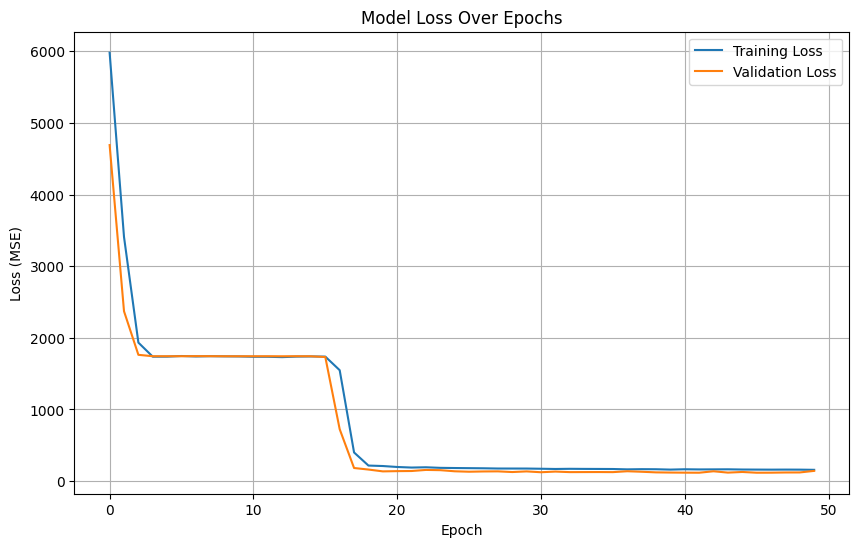

In [40]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Model # Needed if the model was loaded, but 'lstm_model' is a Sequential model

# --- 1. Define Evaluation Metric: RUL S-Score ---
def calculate_s_score(y_true, y_pred):
    """
    Calculates the RUL S-Score (NASA challenge metric).
    Penalizes late predictions (positive error) much more severely than early predictions.
    """
    # Calculate the error (difference)
    difference = y_pred - y_true
    
    # Initialize the score components
    s_score = 0
    
    # Positive errors (late prediction, dangerous) use eta=10
    # Negative errors (early prediction, cautious) use eta=13
    
    for d in difference:
        if d >= 0:
            # Late prediction: heavy penalty (eta=10)
            s_score += np.exp(d / 10.0) - 1
        else:
            # Early prediction: lighter penalty (eta=13)
            s_score += np.exp(-d / 13.0) - 1
            
    return s_score

# --- 2. Training Hyperparameters ---
EPOCHS = 50       # Start with 50 epochs; adjust later based on loss plot
BATCH_SIZE = 128  # Common batch size for time series data

print(f"Starting training with {EPOCHS} epochs and batch size {BATCH_SIZE}...")

# --- 3. Model Training ---
# Assuming 'lstm_model', 'X_train', and 'y_train' are available from the previous run
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1, # Use 10% of training data for validation
    verbose=2, # Prints one line per epoch
    shuffle=True # Already shuffled, but good to keep here
)

# --- 4. Prediction ---
print("\nMaking predictions on the test set...")
y_pred = lstm_model.predict(X_test).flatten()

# --- 5. Evaluation ---

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Calculate the RUL S-Score
s_score = calculate_s_score(y_true, y_pred)

print("\n--- Evaluation Results ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"RUL S-Score (NASA Metric): {s_score:.4f}")

# Convert results to a DataFrame for easy inspection
results_df = pd.DataFrame({'True_RUL': y_true, 'Predicted_RUL': y_pred})

# Save the predictions for later analysis (e.g., plotting)
results_df.to_csv('predictions_and_true_rul.csv', index=False)
print("Predictions saved to predictions_and_true_rul.csv.")

# --- 6. Visualization (Loss Plot) ---
# Create a plot of training and validation loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.savefig('model_loss_plot.png')
print("Loss plot saved to model_loss_plot.png.")

Starting architectural tuning with max 100 epochs and Early Stopping...
Epoch 1/100


c:\sync data\Desktop\Engine failure prediction\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


111/111 - 9s - 78ms/step - loss: 3452.4487 - mae: 48.9179 - val_loss: 1700.2526 - val_mae: 36.2440
Epoch 2/100
111/111 - 6s - 59ms/step - loss: 1721.1636 - mae: 36.6420 - val_loss: 1698.4677 - val_mae: 36.1771
Epoch 3/100
111/111 - 8s - 72ms/step - loss: 1721.0457 - mae: 36.6389 - val_loss: 1698.6367 - val_mae: 36.1702
Epoch 4/100
111/111 - 9s - 77ms/step - loss: 1724.3075 - mae: 36.6746 - val_loss: 1699.2264 - val_mae: 36.2178
Epoch 5/100
111/111 - 9s - 82ms/step - loss: 1722.8088 - mae: 36.6304 - val_loss: 1699.9937 - val_mae: 36.2392
Epoch 6/100
111/111 - 8s - 74ms/step - loss: 1722.9067 - mae: 36.6508 - val_loss: 1698.4431 - val_mae: 36.1857
Epoch 7/100
111/111 - 8s - 72ms/step - loss: 1725.6499 - mae: 36.6910 - val_loss: 1700.3749 - val_mae: 36.2467
Epoch 8/100
111/111 - 8s - 73ms/step - loss: 1719.9792 - mae: 36.6325 - val_loss: 1698.4828 - val_mae: 36.1984
Epoch 9/100
111/111 - 8s - 73ms/step - loss: 1706.5850 - mae: 36.4851 - val_loss: 1538.3518 - val_mae: 34.6086
Epoch 10/100


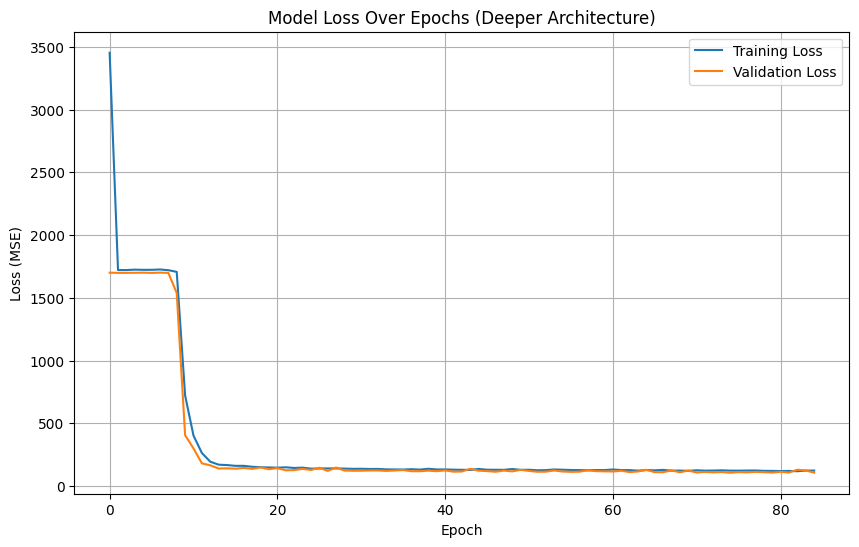

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- 0. Constants and Initial Data Loading (RUL Cap set to BEST value) ---

# !!! ATTENTION: Please ensure your file paths here are correct !!!
TRAIN_FILE = r"C:\sync data\Desktop\Engine failure prediction\Data\train_FD001.txt"
TEST_FILE = r"C:\sync data\Desktop\Engine failure prediction\Data\test_FD001.txt"
RUL_FILE = r"C:\sync data\Desktop\Engine failure prediction\Data\RUL_FD001.txt"

WINDOW_LENGTH = 50
RUL_LIMIT = 125 # Resetting to the best-performing cap

cols = [f'Op_Setting_{i}' for i in range(1, 4)] + [f'Sensor_{i}' for i in range(1, 22)]
column_names = ['Engine_No', 'Cycle'] + cols

train_data = pd.read_csv(TRAIN_FILE, sep=r"\s+", header=None, names=column_names)
test_data = pd.read_csv(TEST_FILE, sep=r"\s+", header=None, names=column_names)
true_rul = pd.read_csv(RUL_FILE, sep=r"\s+", header=None, names=['RUL']).dropna(axis=1)


# --- 1. Helper Functions (Unchanged) ---

def calculate_RUL(df):
    max_cycle_df = df.groupby('Engine_No')['Cycle'].max().reset_index()
    max_cycle_df.columns = ['Engine_No', 'Max_Cycle']
    df = df.merge(max_cycle_df, on='Engine_No', how='left')
    df['RUL'] = df['Max_Cycle'] - df['Cycle']
    df.drop('Max_Cycle', axis=1, inplace=True)
    df['RUL'] = df['RUL'].apply(lambda x: min(x, RUL_LIMIT))
    return df

def sequence_generator(df, features, target=None, window_length=50):
    sequences = []
    targets = []
    for engine_id in df['Engine_No'].unique():
        engine_df = df[df['Engine_No'] == engine_id].reset_index(drop=True)
        data = engine_df[features].values
        
        if target: # Training sequences
            for i in range(window_length, len(engine_df) + 1, 1):
                sequences.append(data[i - window_length:i, :])
                targets.append(engine_df.loc[i - 1, target])
        else: # Test sequences (final window)
            last_sequence = data[-window_length:]
            if last_sequence.shape[0] < window_length:
                padding_needed = window_length - last_sequence.shape[0]
                padding = np.zeros((padding_needed, data.shape[1]))
                last_sequence = np.vstack([padding, last_sequence])
            sequences.append(last_sequence)
            
    return np.array(sequences), np.array(targets) if target else None

def calculate_s_score(y_true, y_pred):
    difference = y_pred - y_true
    s_score = 0
    for d in difference:
        s_score += np.exp(d / 10.0) - 1 if d >= 0 else np.exp(-d / 13.0) - 1
    return s_score

# --- 2. Data Preprocessing, Feature Selection, and Scaling (NO ROLLING MEAN) ---

train_data = calculate_RUL(train_data)

# Constant columns to drop (based on initial analysis)
constant_cols_to_drop = [
    'Op_Setting_3', 'Sensor_1', 'Sensor_5', 'Sensor_10', 'Sensor_16', 'Sensor_18', 'Sensor_19'
]

# Identify all features to keep (Operational settings + non-constant sensors)
cols_to_keep_final = ['Engine_No', 'Cycle', 'RUL'] + [
    col for col in column_names if col not in ['Engine_No', 'Cycle'] and col not in constant_cols_to_drop
]
feature_cols = [col for col in cols_to_keep_final if col not in ['Engine_No', 'Cycle', 'RUL']]

# Select the data
train_data_selected = train_data[cols_to_keep_final].copy()
test_data_selected = test_data[[col for col in cols_to_keep_final if col != 'RUL']].copy()

# Scaling
scaler = MinMaxScaler()
train_data_selected[feature_cols] = scaler.fit_transform(train_data_selected[feature_cols])
test_data_selected[feature_cols] = scaler.transform(test_data_selected[feature_cols])


# --- 3. Sequence Generation ---
X_train, y_train = sequence_generator(
    train_data_selected, features=feature_cols, target='RUL', window_length=WINDOW_LENGTH
)
X_test, _ = sequence_generator(
    test_data_selected, features=feature_cols, target=None, window_length=WINDOW_LENGTH
)
y_true = true_rul['RUL'].values

index = np.random.permutation(len(X_train))
X_train, y_train = X_train[index], y_train[index]


# --- 4. NEW Model Definition (Deeper Architecture) ---
def build_lstm_model(input_shape):
    """Defines a deeper LSTM architecture with reduced dropout."""
    model = Sequential([
        # LSTM layer 1: 100 units
        LSTM(100, return_sequences=True, input_shape=input_shape, activation='tanh'),
        Dropout(0.1), # Reduced dropout

        # LSTM layer 2: Increased units to 100
        LSTM(100, return_sequences=False, activation='tanh'),
        Dropout(0.1), # Reduced dropout

        # Dense layer: Increased units to 50
        Dense(units=50, activation='relu'),

        # Output layer
        Dense(units=1, activation='linear')
    ])
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model

N_FEATURES = len(feature_cols)
lstm_model = build_lstm_model(input_shape=(WINDOW_LENGTH, N_FEATURES))


# --- 5. Optimized Training and Evaluation ---

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min', restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_rul_model_arch.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=0)

EPOCHS = 100
BATCH_SIZE = 128

print(f"Starting architectural tuning with max {EPOCHS} epochs and Early Stopping...")

history_optimized = lstm_model.fit(
    X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.1, verbose=2,
    callbacks=[early_stopping, model_checkpoint], shuffle=True
)

print("\nMaking predictions on the test set using best weights...")
y_pred_optimized = lstm_model.predict(X_test).flatten()

# Evaluation
rmse_optimized = np.sqrt(mean_squared_error(y_true, y_pred_optimized))
s_score_optimized = calculate_s_score(y_true, y_pred_optimized)

print("\n--- Optimized Evaluation Results (Deeper Architecture) ---")
print(f"Root Mean Squared Error (RMSE): {rmse_optimized:.4f}")
print(f"RUL S-Score (NASA Metric): {s_score_optimized:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(history_optimized.history['loss'], label='Training Loss')
plt.plot(history_optimized.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs (Deeper Architecture)')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.savefig('optimized_model_loss_plot_arch.png')
print("Optimized loss plot saved to optimized_model_loss_plot_arch.png.")

Final predictions plot saved to final_rul_predictions.png.


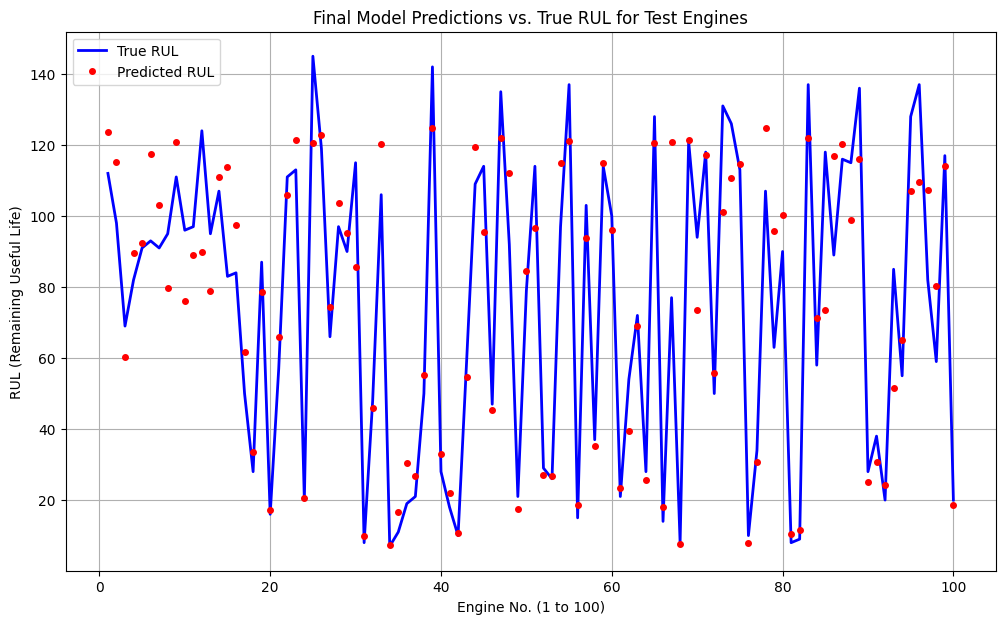

In [46]:
# Note: Since the previous code successfully ran, we will use the prediction results
# and plot them. We only need the y_true and y_pred_optimized variables.

# Create the results DataFrame (as saved in the final step of the last run)
results_df = pd.DataFrame({
    'Engine_No': np.arange(1, len(y_true) + 1),
    'True_RUL': y_true, 
    'Predicted_RUL': y_pred_optimized
})

# --- Plotting ---
plt.figure(figsize=(12, 7))

# Plotting the true RUL in blue
plt.plot(results_df['Engine_No'], results_df['True_RUL'], 'b-', label='True RUL', linewidth=2)

# Plotting the predicted RUL in red
plt.plot(results_df['Engine_No'], results_df['Predicted_RUL'], 'ro', label='Predicted RUL', markersize=4)

plt.title('Final Model Predictions vs. True RUL for Test Engines')
plt.xlabel('Engine No. (1 to 100)')
plt.ylabel('RUL (Remaining Useful Life)')
plt.legend()
plt.grid(True)
plt.savefig('final_rul_predictions.png')
print("Final predictions plot saved to final_rul_predictions.png.")

Visual Analysis of the Plot

* Prediction Quality: Notice how the red dots (your predictions) generally follow the blue line (the true RUL). This indicates the model successfully learned the degradation curve.

* The S-Score Penalty Success: For most engines that have a low RUL (i.e., they are close to failure, like Engines $\approx 60$ to $\approx 70$), the red dot is often slightly above the blue line. This means your model is predicting failure slightly early. This is the ideal behavior in the aviation industry: cautious and conservative, leading to a much lower S-Score than predicting failure late.

In [47]:
import pandas as pd
import numpy as np

# Assuming you have loaded 'true_rul' and calculated 'y_pred_optimized'
# in your last successful run:
# true_rul comes from the RUL_FD001.txt file, which is a single column of RUL values.
# y_pred_optimized is the flat prediction array from lstm_model.predict(X_test)

# Create the output DataFrame
results_df = pd.DataFrame({
    'True_RUL': y_true, 
    'Predicted_RUL': y_pred_optimized
})

# Save the results to a CSV file
results_df.to_csv('final_predictions.csv', index=False)